In [16]:
import pandas as pd
import numpy as np
import sys
import os
notebook_dir = os.getcwd() 
src_path = os.path.abspath(os.path.join(notebook_dir, '..'))
project_path = os.path.abspath(os.path.join(src_path, '..'))
sys.path.append(src_path)
sys.path.append(project_path)
from src.database import DatabaseManager
import pyarrow.parquet as pq
db = DatabaseManager()

In [17]:
draft_features = pd.read_parquet(f'{project_path}/data/alpha_20_min_patchgames_10.parquet')
draft_features['draft_diff'].describe()

count    204599.000000
mean          0.000005
std           0.051518
min          -0.348696
25%          -0.029914
50%          -0.000094
75%           0.030054
max           0.336059
Name: draft_diff, dtype: float64

In [18]:
query_matches = '''
    SELECT id as match_id, "gameVersionId", "didRadiantWin", 
           radiant_draft_score, dire_draft_score 
    FROM match_details
'''
matches = db.select_to_df(query_matches)

query_ratings = '''
    WITH team_stats AS (
        SELECT 
            match_id,
            is_radiant,
            AVG(mu) as avg_mu,
            STDDEV(mu) as std_mu,
            MAX(mu) as max_mu,
            SUM(sigma) as total_sigma
        FROM rating_history
        GROUP BY match_id, is_radiant
    )
    SELECT 
        r.match_id,
        r.avg_mu as radiant_avg_mu, 
        r.std_mu as radiant_std_mu, 
        r.max_mu as radiant_max_mu, 
        r.total_sigma as radiant_total_sigma,
        d.avg_mu as dire_avg_mu, 
        d.std_mu as dire_std_mu, 
        d.max_mu as dire_max_mu, 
        d.total_sigma as dire_total_sigma
    FROM team_stats r
    JOIN team_stats d ON r.match_id = d.match_id
    WHERE r.is_radiant = true AND d.is_radiant = false;
'''
ratings = db.select_to_df(query_ratings)

df = pd.merge(matches, ratings, on='match_id', how='inner')

df_full = df.dropna(subset=[
    'radiant_avg_mu', 'dire_avg_mu', 
    'radiant_draft_score', 'dire_draft_score', 
    'gameVersionId'
]).copy()

df_full.fillna(0, inplace=True)
df_full = pd.merge(
    df_full,
    draft_features,
    on='match_id'
)
df_full['mu_diff'] = df_full['radiant_avg_mu'] - df_full['dire_avg_mu']
df_full['std_diff'] = df_full['radiant_std_mu'] - df_full['dire_std_mu']
df_full['max_mu_diff'] = df_full['radiant_max_mu'] - df_full['dire_max_mu']
df_full['sigma_total_diff'] = df_full['radiant_total_sigma'] - df_full['dire_total_sigma']

In [19]:
df_full[df_full['gameVersionId'] > 72].sort_values(by='gameVersionId', ascending=True)

,match_id,gameVersionId,didRadiantWin,radiant_draft_score,dire_draft_score,radiant_avg_mu,radiant_std_mu,radiant_max_mu,radiant_total_sigma,dire_avg_mu,dire_std_mu,dire_max_mu,dire_total_sigma,draft_diff,label,mu_diff,std_diff,max_mu_diff,sigma_total_diff
148211,3074348922,73,True,0.522455,0.484872,25.633952,4.455540,31.773456,33.247976,25.298248,1.794268,26.765444,34.190931,0.003729,1,0.335705,2.661273,5.008011,-0.942955
148210,3074285446,73,True,0.502314,0.460210,36.052141,4.214562,39.369621,36.632568,26.887599,3.342589,31.833557,35.063134,-0.194596,1,9.164543,0.871973,7.536064,1.569434
148209,3074248534,73,True,0.515562,0.487144,24.348685,4.695943,30.992095,33.410860,26.623535,1.834583,27.894133,34.366140,0.070517,1,-2.274850,2.861360,3.097963,-0.955280
148208,3074189894,73,True,0.509231,0.489684,35.728827,4.243014,39.046558,36.700147,27.184592,3.307429,32.093129,35.103437,0.006059,1,8.544235,0.935585,6.953429,1.596710
148207,3074176776,73,False,0.473100,0.498701,25.360082,4.501035,31.599859,33.593608,25.581253,1.800068,27.009809,34.561153,0.135895,0,-0.221171,2.700966,4.590050,-0.967545
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133910,8809600367,183,True,0.546750,0.545445,49.446735,4.155296,55.581099,24.154633,49.033525,7.466429,58.217627,23.612821,-0.016026,1,0.413209,-3.311133,-2.636528,0.541813
22747,8776543835,183,True,0.573775,0.568914,45.399545,4.550382,52.226217,23.427819,49.488393,1.301173,51.528999,23.298618,-0.055334,1,-4.088848,3.249209,0.697218,0.129202
25414,8777105432,183,True,1.019807,0.988214,29.982987,4.646199,36.824274,64.741190,33.821962,2.018436,36.857671,52.624989,0.080199,1,-3.838975,2.627764,-0.033397,12.116201
30873,8778803034,183,False,0.962176,0.980029,34.745628,2.861138,38.063939,52.875606,33.240342,4.723301,41.179586,52.500418,-0.012445,0,1.505286,-1.862163,-3.115647,0.375188


In [20]:
df_train = df_full[(df_full['gameVersionId'] <= 178) & (df_full['gameVersionId'] > 72)].copy()
df_test = df_full[(df_full['gameVersionId'] > 178) & (df_full['gameVersionId'] > 72)].copy()
features = ['mu_diff', 'std_diff', 'max_mu_diff', 'sigma_total_diff', 'draft_diff']
X_train = df_train[features].values
X_test = df_test[features].values
y_train = df_train['didRadiantWin'].astype('int').values
y_test = df_test['didRadiantWin'].astype('int').values

In [21]:
from sklearn.preprocessing import PowerTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
log_reg_pipeline = Pipeline([
    ('pt', PowerTransformer()),
    ('model', LogisticRegression(max_iter=1000, solver='saga'))
])

In [22]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"Cross-validation accuracies: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (± {cv_scores.std():.4f})")

Cross-validation accuracies: [0.61406862 0.61475795 0.61341062 0.61281529 0.61469528]
Mean CV Accuracy: 0.6139 (± 0.0007)


         Feature  Coefficient
         mu_diff     0.500217
sigma_total_diff    -0.238466
      draft_diff     0.138950
        std_diff     0.032455
     max_mu_diff     0.027008
Test set accuracy: 0.5887538852783272
              precision    recall  f1-score   support

           0       0.57      0.55      0.56     16897
           1       0.60      0.62      0.61     18493

    accuracy                           0.59     35390
   macro avg       0.59      0.59      0.59     35390
weighted avg       0.59      0.59      0.59     35390



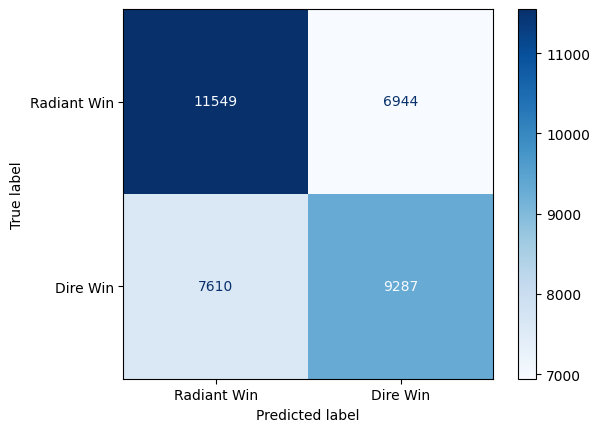

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
log_reg_pipeline.fit(X_train, y_train)
y_pred = log_reg_pipeline.predict(X_test)

coefs = log_reg_pipeline.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefs,
    'Abs_Magnitude': np.abs(coefs)
})

coef_df = coef_df.sort_values(by='Abs_Magnitude', ascending=False).drop(columns=['Abs_Magnitude'])
print(coef_df.to_string(index=False))
print(f'Test set accuracy: {accuracy_score(y_test, y_pred)}')
print(f'{classification_report(y_test, y_pred)}')
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Radiant Win', 'Dire Win'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [24]:
# import joblib
# joblib.dump(log_reg_pipeline, f'{project_path}/src/ml_models/log_reg_model.joblib')